### Spectral clustering on the autonomous Duffing system

In [10]:
import sys

sys.path.append("..")
import numpy as np
from src import (
    SpectralClusteringConfig,
    calculate_spectral_indicators,
    compute_weight_matrix,
    calculate_num_clusters_and_max_eigengap,
    calculate_eigenvalues,
    ode_autonomous_duffing,
    generate_initial_conditions,
    simulate_trajectories,
    plot_clusters,
    plot_clusters_local_maxs,
    plot_eigengaps_vs_index,
    plot_eigengaps_vs_sparsity,
    plot_eigenvalues_vs_index,
    sparsify,
    find_clusters,
    find_local_maxima,
)

np.set_printoptions(precision=3, suppress=True)
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
params = SpectralClusteringConfig(
    num_dimensions=2,
    t_span=(0, 4 * np.pi),
    t_steps=300,
    x_min=-1.6,
    x_max=1.6,
    y_min=-1.0,
    y_max=1.0,
    grid_spacing=0.05,
    max_clusters=50,
    num_radii=50,
)

In [12]:
initial_conditions = generate_initial_conditions(params)
trajectories = simulate_trajectories(ode_autonomous_duffing, initial_conditions, params)
print("(Num trajectories, t_steps, num_dimension) =", trajectories.shape)

(Num trajectories, t_steps, num_dimension) = (2665, 300, 2)


In [13]:
weight_matrix = compute_weight_matrix(trajectories)

In [14]:
max_weight = np.max(weight_matrix)
print(f"Maximum weight in weight matrix: {max_weight:.3f}")
default_diagonal_constant = max_weight * 1e7

Maximum weight in weight matrix: 78.109


Sparsification of 90% achieved using 1.307 as the sparsification radius.
similarity_matrix =
 [[7.811e+08 1.401e+01 6.461e+00 ... 0.000e+00 0.000e+00 0.000e+00]
 [1.401e+01 7.811e+08 1.185e+01 ... 0.000e+00 0.000e+00 0.000e+00]
 [6.461e+00 1.185e+01 7.811e+08 ... 0.000e+00 0.000e+00 0.000e+00]
 ...
 [0.000e+00 0.000e+00 0.000e+00 ... 7.811e+08 1.185e+01 6.461e+00]
 [0.000e+00 0.000e+00 0.000e+00 ... 1.185e+01 7.811e+08 1.401e+01]
 [0.000e+00 0.000e+00 0.000e+00 ... 6.461e+00 1.401e+01 7.811e+08]]
eigvectors.shape = (2665, 50)
50 eigvals = [3.0e-18 8.8e-09 9.3e-09 9.4e-09 1.4e-08 2.1e-08 2.4e-08 4.0e-08 4.2e-08
 4.6e-08 4.6e-08 5.3e-08 5.3e-08 5.7e-08 6.5e-08 6.5e-08 7.8e-08 8.2e-08
 8.6e-08 8.6e-08 8.8e-08 8.9e-08 8.9e-08 9.4e-08 9.6e-08 9.9e-08 1.0e-07
 1.0e-07 1.1e-07 1.1e-07 1.1e-07 1.1e-07 1.1e-07 1.2e-07 1.3e-07 1.3e-07
 1.3e-07 1.3e-07 1.3e-07 1.4e-07 1.4e-07 1.4e-07 1.5e-07 1.5e-07 1.5e-07
 1.5e-07 1.6e-07 1.6e-07 1.6e-07 1.6e-07]


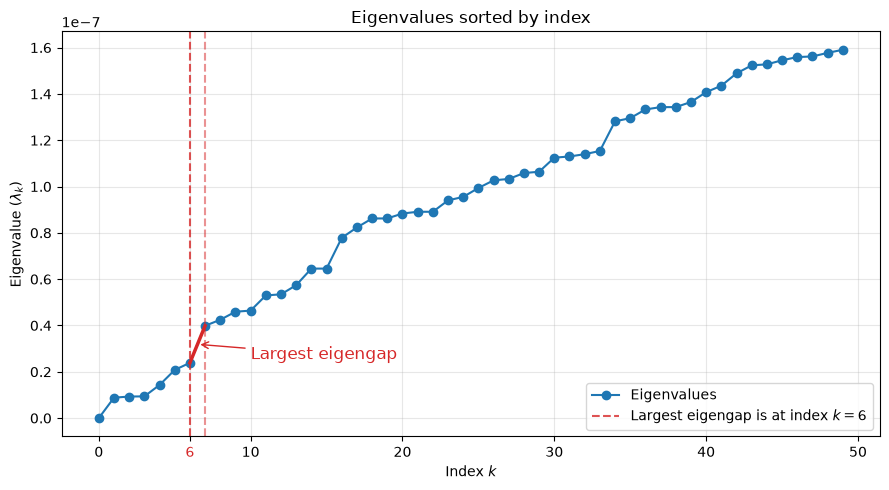

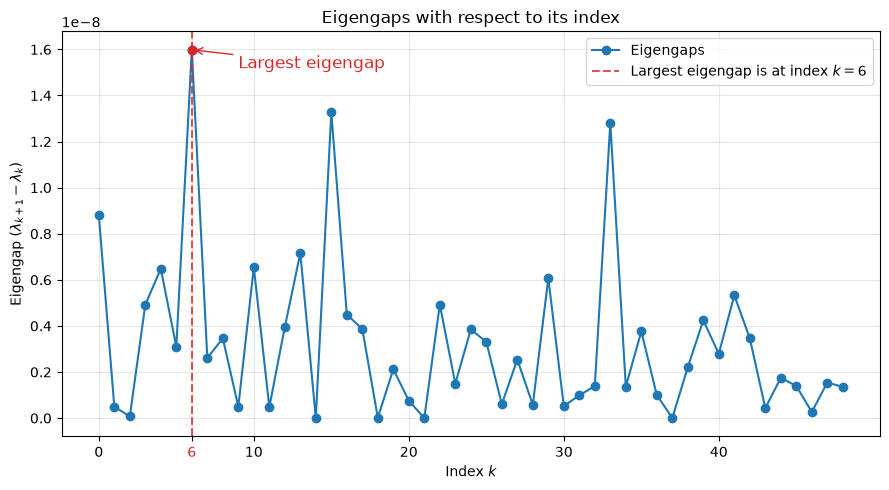

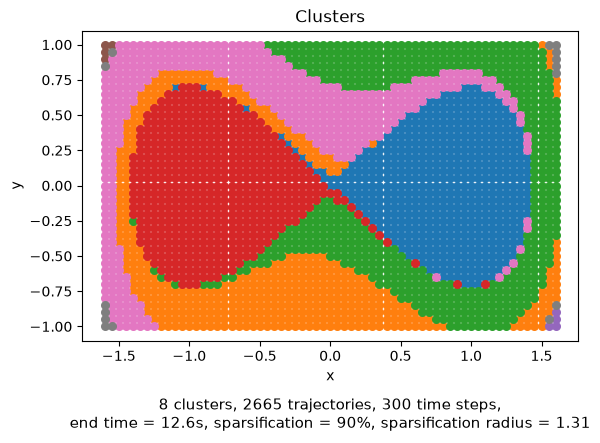

In [15]:
# Option A: esparsify at 90%
similarity_matrix, sparsification_radius, sparsification_percent = sparsify(
    weight_matrix, sparsification_percent=90
)
print(
    f"Sparsification of {sparsification_percent * 100:.0f}% achieved "
    f"using {sparsification_radius:.3f} as the sparsification radius."
)
np.fill_diagonal(similarity_matrix, default_diagonal_constant)
print("similarity_matrix =\n", similarity_matrix)
eigvals, eigvectors = calculate_eigenvalues(similarity_matrix, params.max_clusters)
print("eigvectors.shape =", eigvectors.shape)
print(
    len(eigvals),
    "eigvals =",
    np.array2string(eigvals, formatter={"float_kind": lambda x: f"{x:.1e}"}),
)
plot_eigenvalues_vs_index(eigvals, subfolder="autonomous")
plot_eigengaps_vs_index(eigvals, subfolder="autonomous")
num_clusters, diff_max = calculate_num_clusters_and_max_eigengap(eigvals)
labels = find_clusters(num_clusters, eigvectors)
plot_clusters(
    initial_conditions,
    labels,
    num_clusters,
    sparsification_radius,
    sparsification_percent,
    params,
    subfolder="autonomous",
)

In [16]:
# Option B: adaptive method
# Choose the sparsification radii that maximize the largest eigengap
result = calculate_spectral_indicators(weight_matrix, default_diagonal_constant, params)

local_maxs_indices = [31, 37, 40]
radii[local_maxs_indices] = [1.244 1.426 1.517]
Local maximum #1
Sparsification radius: 1.244, Sparsification percent: 89.04%, Clusters: 17, Max eigengap: 1.98664e-08


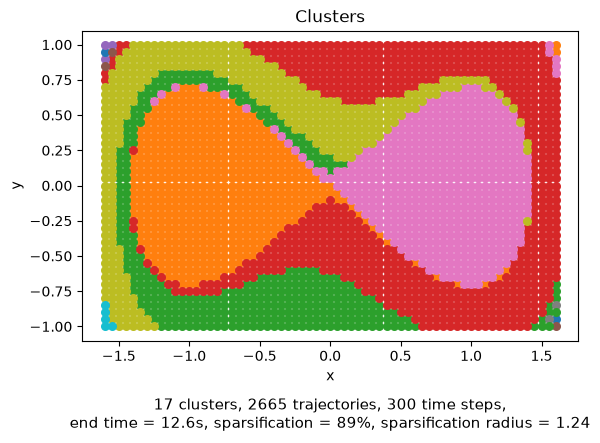

Local maximum #2
Sparsification radius: 1.426, Sparsification percent: 91.64%, Clusters: 8, Max eigengap: 1.45059e-08


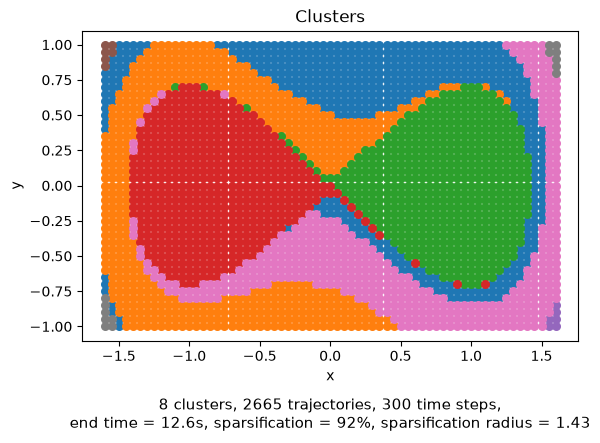

Local maximum #3
Sparsification radius: 1.517, Sparsification percent: 92.79%, Clusters: 8, Max eigengap: 1.33099e-08


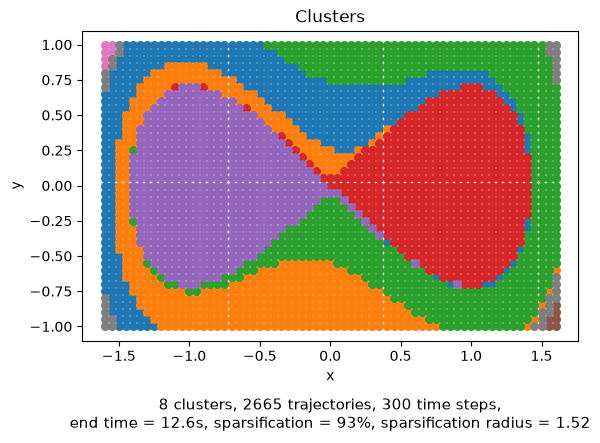

In [17]:
local_maxs_indices = find_local_maxima(result.normalized_eigengaps)
print("local_maxs_indices =", local_maxs_indices)
print("radii[local_maxs_indices] =", result.sparsification_radii[local_maxs_indices])
plot_clusters_local_maxs(
    local_maxs_indices,
    result,
    initial_conditions,
    params,
    subfolder="autonomous_local_maxs",
)

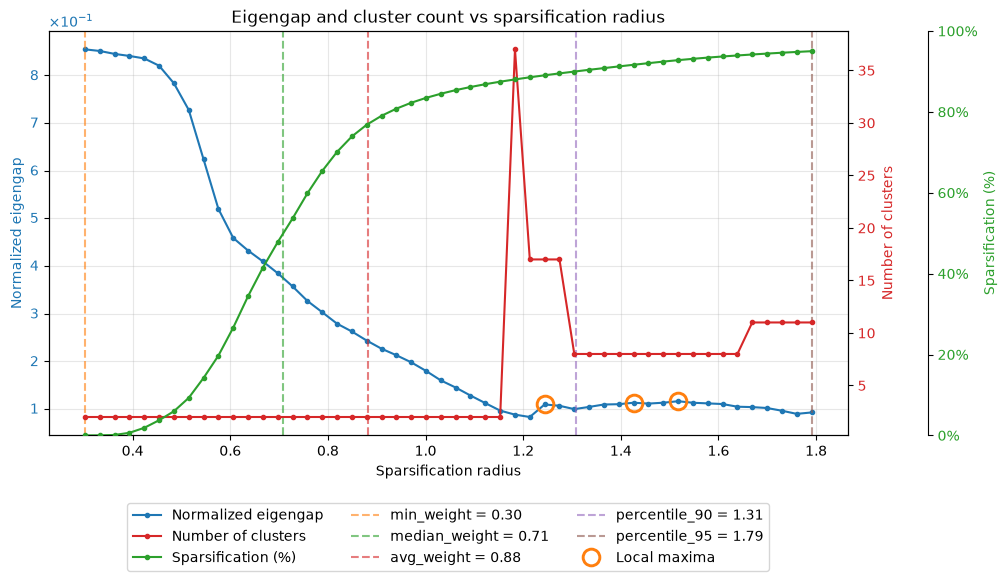

In [18]:
plot_eigengaps_vs_sparsity(
    result,
    params,
    eigengap_local_maxima_indices=local_maxs_indices,
    subfolder="autonomous_local_maxs",
)